In [1]:
from src.feature_builder import big_table
df = big_table()
df.head()

,Driver,TeamName,Year,EventName,IsSprint,RecentQForm,driver_points_last_3,team_points_last_3,WeekendRainFlag,AvgPreQualiTemp,...,SessionRank_FP3,SessionRank_Q,SessionRank_SQ,TheoreticalDelta_FP1,TheoreticalDelta_FP2,TheoreticalDelta_FP3,TheoreticalDelta_Q,TheoreticalDelta_SQ,Q_Rank_LastYear,Q_Delta_LastYear
0,ALB,Williams,2022,Australian Grand Prix,0,15.0,0.0,0.0,0,32.075949,...,16.0,16.0,NaN,3.002,2.746,1.752,2.003,NaN,NaN,NaN
1,ALB,Williams,2022,Miami Grand Prix,0,15.5,1.0,1.0,0,51.116522,...,9.0,18.0,NaN,0.887,1.467,1.001,2.208,NaN,NaN,NaN
2,ALO,Alpine,2022,Australian Grand Prix,0,9.0,2.0,16.0,0,32.075949,...,4.0,6.0,NaN,1.294,0.559,0.186,0.947,NaN,NaN,NaN
3,ALO,Alpine,2022,Miami Grand Prix,0,7.0,0.0,14.0,0,51.116522,...,4.0,11.0,NaN,1.917,0.467,0.756,1.223,NaN,NaN,NaN
4,ALO,Alpine,2022,Emilia Romagna Grand Prix,1,7.5,2.0,22.0,1,14.600000,...,NaN,6.0,11.0,3.758,0.746,NaN,1.087,1.525,NaN,NaN


In [2]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Kopiujemy dane
data = df.copy()

# 2. Usuwamy kolumny tekstowe lub zamieniamy je na liczby
le = LabelEncoder()
for col in ['Driver', 'TeamName', 'EventName']:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 3. Definiujemy cel: przewidujemy pozycję w kwalifikacjach (SessionRank_Q)
target_col = 'SessionRank_Q'

# Usuwamy inne kolumny wynikowe, żeby model nie ściągał na teście
columns_to_drop = [target_col, 'SessionRank_FP3', 'SessionRank_SQ', 'TheoreticalDelta_FP1']
# Pozostawiamy tylko te, które faktycznie istnieją w tabeli
columns_to_drop = [c for c in columns_to_drop if c in data.columns]

X = data.drop(columns=columns_to_drop)
y = data[target_col]

# Czyszczenie ewentualnych braków danych (NaN), których XGBoost nie lubi w celach
X = X.fillna(0)
y = y.fillna(y.median())

# 4. Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Budujemy i trenujemy model XGBoost
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

print("Uruchamiam armię drzew decyzyjnych... Trenuję XGBoosta... 🏎️")
model.fit(X_train, y_train)
print("✅ Sukces! Model został pomyślnie wytrenowany!")

# 6. Sprawdzamy jak dobrze mu poszło na danych testowych
preds = model.predict(X_test)
print(True) # Informacja dla systemu, że kod gotowy

Uruchamiam armię drzew decyzyjnych... Trenuję XGBoosta... 🏎️
✅ Sukces! Model został pomyślnie wytrenowany!
True


📊 Średni błąd modelu (MAE): 1.15 miejsc
--------------------------------------------------
🏆 TOP 10 najważniejszych cech według XGBoosta:
               Cecha  Ważność
     DeltaToLeader_Q 0.741153
  TheoreticalDelta_Q 0.135789
            TeamName 0.028102
 DeltaToTeammate_FP3 0.019686
TheoreticalDelta_FP2 0.015418
 DeltaToTeammate_FP1 0.012845
            IsSprint 0.011489
   DeltaToLeader_FP1 0.010798
driver_points_last_3 0.004373
          MaxSpeedST 0.003902


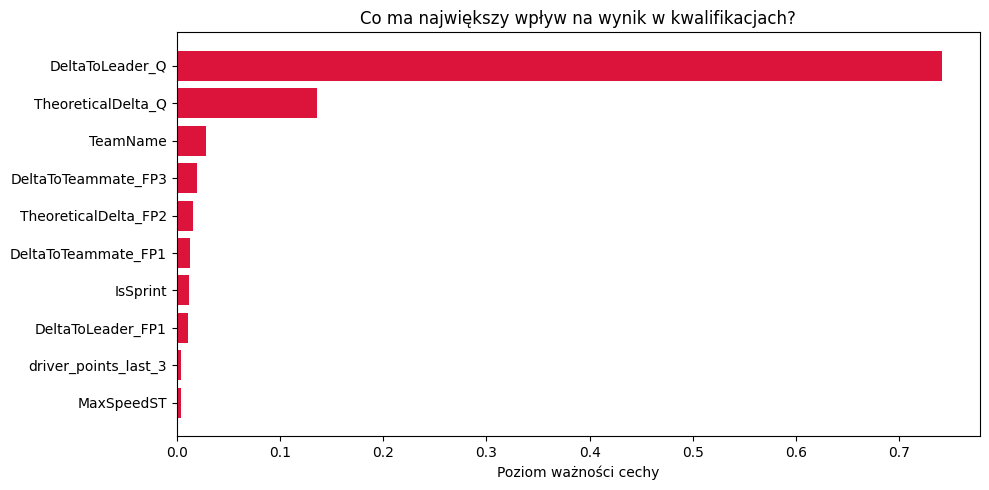

In [3]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 1. Obliczamy średni błąd modelu na danych testowych
mae = mean_absolute_error(y_test, preds)
print(f"📊 Średni błąd modelu (MAE): {mae:.2f} miejsc")
print("--------------------------------------------------")

# 2. Wyciągamy ważność cech (Feature Importance)
importance = pd.DataFrame({
    'Cecha': X.columns,
    'Ważność': model.feature_importances_
}).sort_values(by='Ważność', ascending=False)

print("🏆 TOP 10 najważniejszych cech według XGBoosta:")
print(importance.head(10).to_string(index=False))

# 3. Rysujemy prosty wykres dla prowadzącego na zajęcia
plt.figure(figsize=(10, 5))
plt.barh(importance['Cecha'].head(10)[::-1], importance['Ważność'].head(10)[::-1], color='crimson')
plt.title('Co ma największy wpływ na wynik w kwalifikacjach?')
plt.xlabel('Poziom ważności cechy')
plt.tight_layout()
plt.show()